In [1]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings
from langchain_ollama.llms import OllamaLLM
import time
from langchain.prompts import PromptTemplate
from langchain_core.output_parsers import JsonOutputParser
from langchain_core.output_parsers import StrOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter
from ddgs import DDGS

USER_AGENT environment variable not set, consider setting it to identify your requests.
c:\Users\deyro\anaconda3\envs\Chatbot\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
embeddings = OllamaEmbeddings(model="nomic-embed-text")
llm =OllamaLLM(model='qwen3:4b', temperature=0.7)

In [3]:
urls=["https://indianexpress.com/article/technology/tech-news-technology/google-translate-gemini-ai-real-time-translation-feature-10418293/",
"https://indianexpress.com/article/technology/science/ai-startup-conduit-builds-largest-brain-to-language-dataset-in-underground-lab-10418246/",
"https://indianexpress.com/article/technology/science/ai-startup-conduit-builds-largest-brain-to-language-dataset-in-underground-lab-10418246/"
"https://indianexpress.com/article/technology/artificial-intelligence/trump-moves-to-limit-state-ai-rules-as-critics-warn-of-overreach-what-to-know-10417886/"
]

docs_list = []
for url in urls:
    loaded = WebBaseLoader(url).load()
    docs_list.extend(loaded)

docs_list = [doc for doc in docs_list if doc.page_content.strip()]

In [4]:
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=250, chunk_overlap=50
)
doc_splits = text_splitter.split_documents(docs_list)

In [5]:
vector_store = FAISS.from_documents(doc_splits, embeddings)
retriever = vector_store.as_retriever()

In [6]:
# Router prompt: decide when to use vectorstore or web search
router_prompt = PromptTemplate(
    template=(
        "You are an expert at routing a user question to a vectorstore or web search.\n"
        "Use the vectorstore for questions on LLM agents, prompt engineering, and adversarial attacks.\n"
        "Otherwise, use web search. Give a binary choice 'web_search' or 'vectorstore'.\n"
        "Return a JSON with a single key 'datasource' and no preamble. Question to route: {question}"
    ),
    input_variables=["question"],
)
question_router = router_prompt | llm | JsonOutputParser()

In [7]:
# RAG (Retrieval-Augmented Generation) prompt
rag_prompt = PromptTemplate(
    template=(
        "You are an assistant for question-answering tasks.\n"
        "Use the following retrieved context to answer the question. If you don't know the answer, say so.\n"
        "Use at most four sentences and keep the answer concise.\n"
        "Question: {question}\n"
        "Context: {context}\n"
        "Answer:"
    ),
    input_variables=["question", "context"],  
)
rag_chain = rag_prompt | llm | StrOutputParser()

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

In [8]:
# Retrieval relevance grader prompt
retrieval_prompt = PromptTemplate(
    template=(
        "You are a grader assessing relevance of a retrieved document to a user question.\n"
        "If the document contains keywords related to the user question, grade it as relevant ('yes'); otherwise, 'no'.\n"
        "Return a JSON with a single key 'score' and no preamble.\n"
        "Here is the retrieved document:\n\n{document}\n\n"
        "Here is the user question: {question}"
    ),
    input_variables=["question", "document"],
)
retrieval_grader = retrieval_prompt | llm | JsonOutputParser()

In [9]:
# Define the hallucination grader prompt
hallucination_prompt = PromptTemplate(
    template=(
        "System: You are a grader assessing whether an answer is grounded in a set of facts.\n"
        "Give a binary 'yes' or 'no' indicating whether the answer is supported by the facts. Return a JSON with key 'score'.\n"
        "User\n"
        "Here are the facts:\n"
        "\n-------\n\n{documents}\n\n-------\n"
        "Here is the answer: {generation}"
    ),
    input_variables=["documents", "generation"],
)
hallucination_grader = hallucination_prompt | llm | JsonOutputParser()

In [10]:
# Define the answer usefulness grader prompt
answer_prompt = PromptTemplate(
    template=(
        "You are a grader assessing whether an answer is useful to resolve a question.\n"
        "Give 'yes' or 'no' if the answer is useful. Return a JSON with key 'score'.\n"
        "user\n"
        "Here is the answer:\n"
        "\n-------\n\n{generation}\n\n-------\n"
        "Here is the question: {question}"
    ),
    input_variables=["generation", "question"],
)
answer_grader = answer_prompt | llm | JsonOutputParser()

In [11]:
def web_search_tool(query: str, num_results: int = 5):
    with DDGS() as ddgs:
        results = ddgs.text(query, max_results=num_results)
    
    if not results:
        return "No relevant search results found."
    
    context = "\n".join([res["body"] for res in results if "body" in res])
    return context

In [12]:
from typing_extensions import TypedDict
from typing import List

### The state schema for the workflow
class AgentState(TypedDict):
    question : str
    generation : str
    web_search : str
    documents : List[str]

In [13]:
from langchain.schema import Document

# The state transition functions
def retrieve(state: AgentState) -> AgentState:
    """Retrieve documents from the vectorstore."""
    print("--------------------------RETRIEVE--------------------------")
    question = state["question"]
    docs = retriever.invoke(question)
    return {"documents": docs, "question": question}

In [14]:
def generate(state: AgentState) -> AgentState:
    """Generate an answer using RAG on the retrieved documents."""
    print("--------------------------GENERATE--------------------------")
    question = state["question"]
    documents = state.get("documents", [])
    context_str = format_docs(documents)
    generation = rag_chain.invoke({"question": question, "context": context_str})
    return {"documents": documents, "question": question, "generation": generation}

In [15]:
def grade_documents(state: AgentState) -> AgentState:
    """Check each retrieved document for relevance to the question.
        If any are irrelevant, set web_search flag.
    """
    print("--------------------------CHECK DOCUMENT RELEVANCE--------------------------")
    question = state["question"]
    documents = state["documents"]
    filtered_docs = []
    web_search_flag = "No"
    for doc in documents:
        score = retrieval_grader.invoke({"question": question, "document": doc.page_content})
        grade = score['score']
        if grade.lower() == "yes":
            print("Document relevant.")
            filtered_docs.append(doc)
        else:
            print("Document not relevant.")
            web_search_flag = "Yes"
    return {"documents": filtered_docs, "question": question, "web_search": web_search_flag}

In [16]:
def web_search(state: AgentState) -> AgentState:
    """Perform web search and append results to documents."""
    print("--------------------------WEB SEARCH--------------------------")
    question = state["question"]
    documents = state.get("documents", [])
    search_text = web_search_tool(question)
    web_results_doc = Document(page_content=search_text)
    documents.append(web_results_doc)
    return {"documents": documents, "question": question}

In [17]:
def route_question(state: AgentState) -> str:
    """Decide whether to use web search or RAG based on the question.
        Returns the next node name.
    """
    print("--------------------------ROUTE QUESTION--------------------------")
    question = state["question"]
    source = question_router.invoke({"question": question})
    choice = source.get("datasource")
    print(f"Routing decision: {choice}")
    return "websearch" if choice == "web_search" else "retrieve"

In [18]:
def decide_to_generate(state: AgentState) -> str:
    """After grading documents, decide next step:
       If any doc was irrelevant, use web search; else, generate answer.
    """
    print("---DECIDE NEXT STEP---")
    if state.get("web_search") == "Yes":
        print("Decision: Use web search next.")
        return "websearch"
    else:
        print("Decision: Generate answer next.")
        return "generate"

In [19]:
def grade_generation_v_documents_and_question(state: AgentState) -> str:
    """Check if the generated answer is grounded in the documents and addresses the question.
        Returns 'useful', 'not useful', or 'not supported'.
    """
    print("---GRADE GENERATION---")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]
    # Check grounding
    docs_text = format_docs(documents)
    score = hallucination_grader.invoke({"documents": docs_text, "generation": generation})
    grade = score['score']
    if grade.lower() == "yes":
        print("Generation is grounded in documents.")
        # Check if it answers the question
        score = answer_grader.invoke({"generation": generation, "question": question})
        ans_grade = score['score']
        if ans_grade.lower() == "yes":
            print("Generation answers the question.")
            return "useful"
        else:
            print("Generation does not answer the question.")
            return "not useful"
    else:
        print("Generation is not grounded. Need to regenerate.")
        return "not supported"


In [20]:
from langgraph.graph import END, StateGraph

# Build the state graph workflow
workflow = StateGraph(AgentState)
# Add nodes
workflow.add_node("websearch", web_search)
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents", grade_documents)
workflow.add_node("generate", generate)
# Set conditional entry (first step) based on routing
workflow.set_conditional_entry_point(
    route_question,
    {"websearch": "websearch", "vectorstore": "retrieve"}
)
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents", decide_to_generate,
    {"websearch": "websearch", "generate": "generate"}
)
workflow.add_edge("websearch", "generate")
workflow.add_conditional_edges(
    "generate", grade_generation_v_documents_and_question,
    {"not supported": "generate", "useful": END, "not useful": "websearch"}
)

In [21]:
app = workflow.compile()

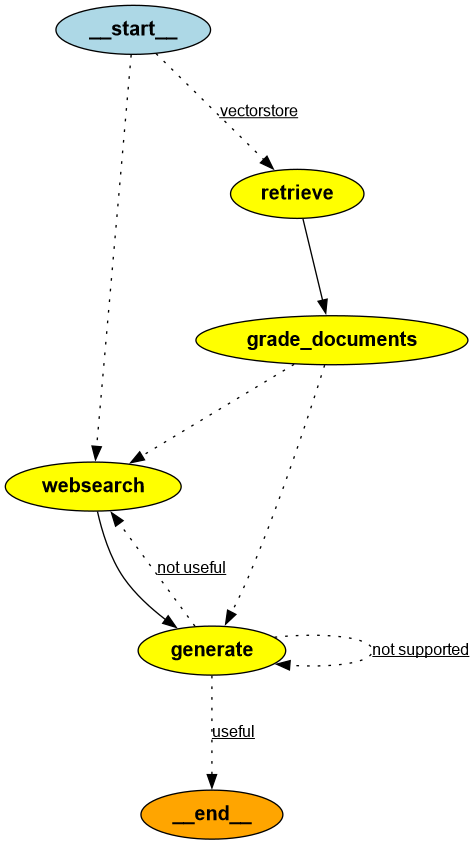

In [22]:
from IPython.display import Image

Image(app.get_graph().draw_png())

In [23]:
from pprint import pprint

inputs = {"question": "What is LLM"}
for output in app.stream(inputs):
    for key, value in output.items():
        pprint(f"Finished node: {key}")
        if "generation" in value:
            print(f"Answer: {value['generation']}")


--------------------------ROUTE QUESTION--------------------------
Routing decision: web_search
--------------------------WEB SEARCH--------------------------
'Finished node: websearch'
--------------------------GENERATE--------------------------
---GRADE GENERATION---
Generation is grounded in documents.
Generation answers the question.
'Finished node: generate'
Answer: A large language model (LLM) is a language model trained with self-supervised machine learning on vast amounts of text, designed for natural language processing tasks like understanding and generating human-like text. LLMs are advanced AI systems built on deep neural networks that process massive datasets to perform a wide range of language-related functions. They are often fine-tuned for specific applications or used as the core capability in modern chatbots. The largest LLMs, such as generative pre-trained transformers (GPTs), are trained on enormous datasets and can describe complex concepts with high accuracy.
